# Particle birth and death — work in progress

This notebook explores lifespan-aware `state_evolution` for interacting particles
that enter and exit the field of view at different times.

**Status:** not yet included in the tutorial series.

In [1]:
import time

import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import DiracIdentityObservation
from dynestyx.simulators import DiscreteTimeSimulator

az.style.use("arviz-white")

## Making `state_evolution` lifespan-aware

`state_evolution` receives the full $N$-vector of carries at every timestep, including
absent particles. Their carries are phantom states sampled from the transition distribution.
To prevent these phantom positions from contaminating the interaction sum or producing `NaN`
from IEEE-754 arithmetic, anchor them at a safe value before computing:

```python
alive  = (t_now >= birth_times) & (t_now <= death_times)
x_safe = jnp.where(alive, x, 0.0)          # anchor absent carries

r      = x_safe[None, :] - x_safe[:, None]
K_pair = jnp.exp(-0.5 * (r / scale)**2)
n_alive = jnp.maximum(alive.astype(float).sum(), 1.0)
interaction_drift = coefficient * jnp.sum(
    alive.astype(float)[None, :] * K_pair * r, axis=1) / n_alive

net_drift = jnp.where(alive, interaction_drift, 0.0)
mean      = x_safe + dt * net_drift
```

1. **`x_safe` substitution** — IEEE 754 gives `0 × NaN = NaN`, so absent carries
   must be replaced before any arithmetic.
2. **`alive_f` masking** — absent particles exert no force on alive ones.

In [2]:
# ---- Parameters ------------------------------------------------------------
N_st          = 15
T_st          = 60
t_st          = jnp.arange(0.0, T_st * 0.1, 0.1)
sigma_st      = 0.3
true_coeff_st = -1.0
true_scale_st =  1.5

# Each particle gets a random birth step, lifespan, and starting position
rng_life = np.random.default_rng(7)
min_life, max_life = 10, 18
birth_steps = rng_life.integers(0, T_st - max_life, size=N_st)
lifespans   = rng_life.integers(min_life, max_life + 1, size=N_st)
death_steps = np.minimum(birth_steps + lifespans - 1, T_st - 1)

# Random birth positions (no background potential in this model)
birth_positions_np = rng_life.uniform(-3.0, 3.0, size=N_st)
birth_pos_st       = jnp.array(birth_positions_np)

birth_times_st = jnp.array(birth_steps) * 0.1
death_times_st = jnp.array(death_steps) * 0.1

alive_grid = ((np.arange(T_st)[:, None] >= birth_steps[None, :]) &
              (np.arange(T_st)[:, None] <= death_steps[None, :]))
print(f"N={N_st} particles, T={T_st} steps, {alive_grid.mean():.0%} alive  "
      f"(avg {alive_grid.sum(0).mean():.1f} steps per particle, "
      f"\u2248{alive_grid.sum(1).mean():.1f} alive per timestep)")

true_params_st = {"coefficient": jnp.array(true_coeff_st),
                  "scale":       jnp.array(true_scale_st)}
data_key_st, svi_key_st = jr.split(jr.PRNGKey(42), 2)
colors_st = plt.cm.tab20(np.linspace(0, 1, N_st))
t_st_np   = np.asarray(t_st)


# ---- Lifespan-aware model --------------------------------------------------
def interacting_particles_lifespan_model(N, obs_times=None, obs_values=None):
    coefficient = numpyro.sample("coefficient", dist.Normal(0.0, 2.0))
    scale       = numpyro.sample("scale",       dist.LogNormal(0.0, 0.5))

    def state_evolution(x, u, t_now, t_next):
        alive   = (t_now >= birth_times_st) & (t_now <= death_times_st)
        alive_f = alive.astype(float)
        dt      = t_next - t_now
        x_safe  = jnp.where(alive, x, birth_pos_st)
        r       = x_safe[None, :] - x_safe[:, None]
        K_pair  = jnp.exp(-0.5 * (r / scale) ** 2)
        n_alive = jnp.maximum(alive_f.sum(), 1.0)
        interaction_drift = (
            coefficient * jnp.sum(alive_f[None, :] * K_pair * r, axis=1) / n_alive
        )
        net_drift = jnp.where(alive, interaction_drift, 0.0)
        mean = x_safe + dt * net_drift
        std  = jnp.sqrt(sigma_st ** 2 * dt) * jnp.ones_like(mean)
        return dist.Independent(dist.Normal(mean, std), 1)

    dynamics = DynamicalModel(
        control_dim=0,
        initial_condition=dist.Independent(
            dist.Normal(birth_pos_st[:N], jnp.ones(N)), 1
        ),
        state_evolution=state_evolution,
        observation_model=DiracIdentityObservation(),
    )
    dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)


# ---- Generate data ---------------------------------------------------------
with DiscreteTimeSimulator():
    synth_st = Predictive(
        interacting_particles_lifespan_model,
        params=true_params_st,
        num_samples=1,
        exclude_deterministic=False,
    )(data_key_st, N=N_st, obs_times=t_st)

obs_st_full = np.asarray(synth_st["observations"].squeeze(0))

obs_st = obs_st_full.copy()
for i in range(N_st):
    obs_st[:birth_steps[i], i] = np.nan
    obs_st[death_steps[i] + 1:, i] = np.nan
obs_st = jnp.array(obs_st)

N=15 particles, T=60 steps, 24% alive  (avg 14.1 steps per particle, ≈3.5 alive per timestep)


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_97436/2265136501.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


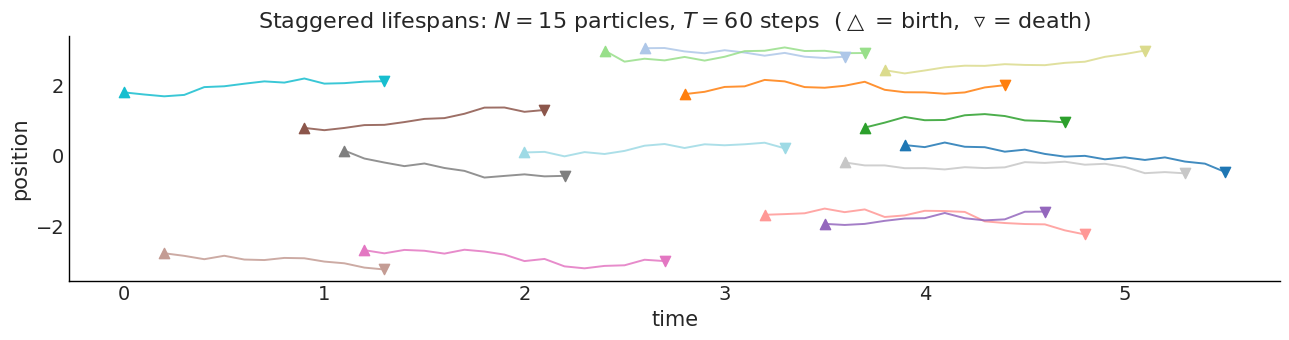

In [3]:
obs_np_st = np.asarray(obs_st)

fig, ax = plt.subplots(figsize=(13, 3.5))
for i in range(N_st):
    alive = ~np.isnan(obs_np_st[:, i])
    ax.plot(t_st_np[alive], obs_np_st[alive, i], color=colors_st[i], lw=1.4, alpha=0.85)
    ax.scatter(t_st_np[birth_steps[i]], obs_np_st[birth_steps[i], i],
               marker="^", s=55, color=colors_st[i], zorder=5)
    ax.scatter(t_st_np[death_steps[i]], obs_np_st[death_steps[i], i],
               marker="v", s=55, color=colors_st[i], zorder=5)
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.set_title(fr"Staggered lifespans: $N={N_st}$ particles, $T={T_st}$ steps  "
             r"($\triangle$ = birth,  $\triangledown$ = death)")
plt.tight_layout()
plt.show()

SVI finished in 2.5s
coefficient:  true -1.0  |  posterior mean -0.485 ± 0.522
scale:        true 1.5   |  posterior mean 0.920 ± 0.302


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_97436/4292694647.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


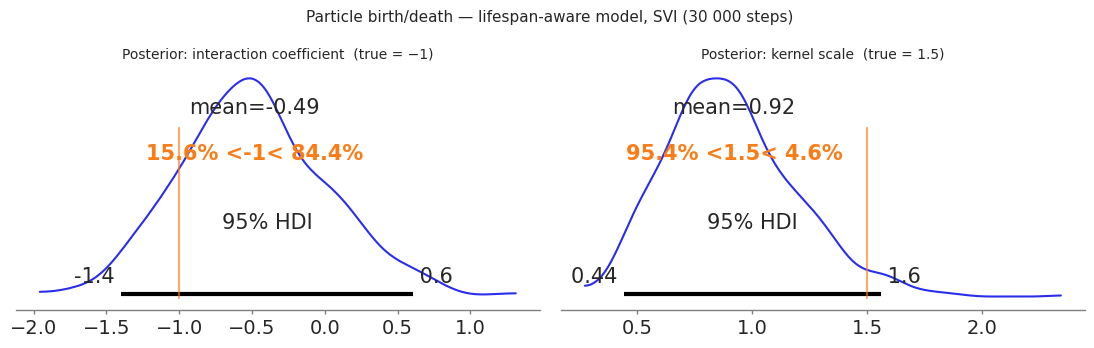

In [4]:
def conditioned_st():
    with DiscreteTimeSimulator():
        interacting_particles_lifespan_model(N=N_st, obs_times=t_st, obs_values=obs_st)


init_st  = {"coefficient": jnp.array(true_coeff_st), "scale": jnp.array(true_scale_st)}
guide_st = AutoNormal(conditioned_st, init_loc_fn=init_to_value(values=init_st))
svi_st   = SVI(conditioned_st, guide_st, optax.adam(2e-3), loss=Trace_ELBO())

t0 = time.time()
svi_res_st = svi_st.run(svi_key_st, num_steps=30000, progress_bar=False)
print(f"SVI finished in {time.time() - t0:.1f}s")

post_st       = guide_st.sample_posterior(jr.PRNGKey(20), svi_res_st.params, sample_shape=(500,))
post_coeff_st = np.asarray(post_st["coefficient"])
post_scale_st = np.asarray(post_st["scale"])
print(f"coefficient:  true {true_coeff_st:+.1f}  |  "
      f"posterior mean {post_coeff_st.mean():+.3f} \u00b1 {post_coeff_st.std():.3f}")
print(f"scale:        true {true_scale_st:.1f}   |  "
      f"posterior mean {post_scale_st.mean():.3f} \u00b1 {post_scale_st.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
az.plot_posterior(post_coeff_st, hdi_prob=0.95, ref_val=true_coeff_st, ax=axes[0])
axes[0].set_title("Posterior: interaction coefficient  (true = \u22121)", fontsize=10)
az.plot_posterior(post_scale_st, hdi_prob=0.95, ref_val=true_scale_st, ax=axes[1])
axes[1].set_title("Posterior: kernel scale  (true = 1.5)", fontsize=10)
fig.suptitle("Particle birth/death \u2014 lifespan-aware model, SVI (30 000 steps)", fontsize=11)
plt.tight_layout()
plt.show()